In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import time

from sipp import *
from trajectory_metrics import *

sys.path.append(os.path.abspath('../common'))
from DO_structs import *
from DO_graphics import *
from DO_searching import *

%matplotlib inline

# Benchmarking and Visualizing Pathfinding Across Diverse Control Sets

In this experiment, we execute the SIPP planner across multiple lattice setups on the same test case query. 
We evaluate standard kinematic primitives alongside different $2^k$-connectivity branching factors to directly compare their trajectory metrics, solution costs, and search spaces. 
Each pipeline run automatically annotates the final trajectory plot with performance statistics and dumps a snapshot file.


In [3]:
def generate_annotated_snapshot(
    name: str,
    control_set,
    environment,
    task_map,
    start,
    goal,
    is_angular: bool = True,
    save_dir: str = "./"
):
    """
    Executes SIPP search for a given control set, generates a visualization snapshot 
    of the trajectory, annotates it with performance metrics, and saves it to a file.
    
    :param name: Identifier for the current run (e.g., 'arena_cs2').
    :param control_set: The ControlSet used for the robot.
    :param environment: The DynamicEnvironment containing obstacles.
    :param task_map: The static grid map.
    :param start: Starting DiscreteState.
    :param goal: Goal DiscreteState.
    :param is_angular: Flag indicating if the path is piecewise-linear (for metric calculation).
    :param save_dir: Directory to save the final image.
    :return: The fully annotated matplotlib Figure object (or None if pathfinding fails).
    """
    
    # 1. Pathfinding phase
    search_space = SIPPSearchSpace(start, 0.0, goal, control_set, environment, R=0, A=0, position_only=True)
    success, path, steps, cost, ast = astar(search_space)
    
    print(f"[{name}] Pathfinding Success: {success} | Cost: {cost}")
    if not success:
        return None
        
    # 2. Robot initialization with the found path
    robot = DynamicObstacle(control_set).set_parametres(R, start.i, start.j, start.theta, path)

    # 3. Create the underlying visualization
    update_sim = create_dynamic_visualizer(
        task_map=task_map,
        obstacle_set=environment.get_dynamic_obstacles_set(),
        show_path=True,
        fast_draw=False,
        make_gif=False,
        robot=robot,
        dpi=200,
        scale=1,
        robot_line_width=3.2,
        obs_line_width=0.0,
        robot_line_segments_alternation='teal,orange',  # Alternating colors for primitives
        robot_line_marker='',                           # Remove default node markers
        robot_line_alpha=1.0,
        jupyter_display=False
    )
    
    # 4. Extract the Figure object from the visualizer's closure
    # This is a necessary hack because the visualizer doesn't expose the Figure directly
    fig = None
    for cell in update_sim.__closure__:
        if hasattr(cell.cell_contents, 'savefig'): 
            fig = cell.cell_contents
            break
            
    if fig is None:
        print(f"[{name}] Error: Could not extract Figure object from the visualizer.")
        return None
        
    # Trigger the visualizer to draw the initial state (tick 0)
    update_sim(0)
    
    # 5. Clean up axes (remove ticks, labels, and borders for a clean snapshot)
    for ax in fig.get_axes():
        ax.set_title("")            
        ax.set_xlabel("")           
        ax.set_ylabel("")           
        ax.set_xticks([])           
        ax.set_yticks([])           
        ax.axis('off')

    # 6. Metrics Calculation
    prim_ids = get_prim_ids(path)
    path_length = sum(control_set.get_primitive(pid).length for pid in prim_ids)
    
    # Safely compute normalized metrics
    v_cost = cost
    v_ang  = (compute_curvature(prim_ids, control_set) / path_length) if path_length > 0 else 0
    v_aol  = (compute_heading_change(prim_ids, control_set, is_angular=is_angular) / path_length) if path_length > 0 else 0
    v_be   = (compute_bending_energy(prim_ids, control_set, is_angular=is_angular) / path_length) if path_length > 0 else 0
    
    # 7. Text Annotation Formatting
    # Using a monospaced font and strict width alignment (:<22) to create a clean table layout
    header_width = 22
    legend_text = (
        f"{'Cost':<{header_width}} : {v_cost:>8.3f}\n"
        f"{'Trajectory Angularity':<{header_width}} : {v_ang:>8.3f}\n"
        f"{'Angle-Over-Length':<{header_width}} : {v_aol:>8.3f}\n"
        f"{'Bending Energy':<{header_width}} : {v_be:>8.3f}"
    )
    
    bbox_props = dict(
        boxstyle="round,pad=0.6,rounding_size=0.2",
        facecolor="#ffcc80", 
        edgecolor="teal",
        linewidth=5.5, 
        alpha=0.9,
    )
    
    # Attach the text box to the primary axis
    ax = fig.get_axes()[-1]
    ax.text(
        0.97, 0.03,             # Bottom-right corner coordinates (relative to axes)
        legend_text, 
        transform=ax.transAxes, 
        fontsize=14, 
        fontfamily='monospace', # Critical for column alignment
        color='black',          
        verticalalignment='bottom', 
        horizontalalignment='right', 
        bbox=bbox_props,
        zorder=100              # Ensure the text is drawn above all map elements
    )
    
    # 8. Save and cleanup
    save_path = f"{save_dir.rstrip('/')}/{name}_{cost:.0f}.png"
    fig.savefig(save_path, bbox_inches='tight', transparent=False, facecolor='white')
    
    # Prevents Jupyter from automatically rendering the intermediate, unannotated figure
    plt.close(fig)
    
    return fig

In [4]:
# Global Search Environment Setup
env_cs = ControlSet().load_primitives("../data/control_set.txt")
task_map = Map()
task_map.read_from_movingai_file("../maps/arena.map")
R = 1
environment = DynamicEnvironment(task_map, R)
environment.load_obstacles_from_dir("../dynamic_obstacles/arena_random/dynamic_obstacle_*.txt", env_cs, max_items=20)
environment.compile_safe_intervals()
start = DiscreteState(39, 5, 7)
goal = DiscreteState(3, 39, 9)

In [5]:
# Control Set Catalog Definition
control_sets = [
    ControlSet().load_primitives("../data/control_set.txt"),
    ControlSet().load_primitives("../data/extended_set.txt"),
    ControlSet().load_primitives("../data/primitives_2k_2.txt"),
    ControlSet().load_primitives("../data/primitives_2k_3.txt"),
    ControlSet().load_primitives("../data/primitives_2k_4.txt"),
    ControlSet().load_primitives("../data/primitives_2k_5.txt"),
]

[arena_basic] Pathfinding Success: True | Cost: 516.729102


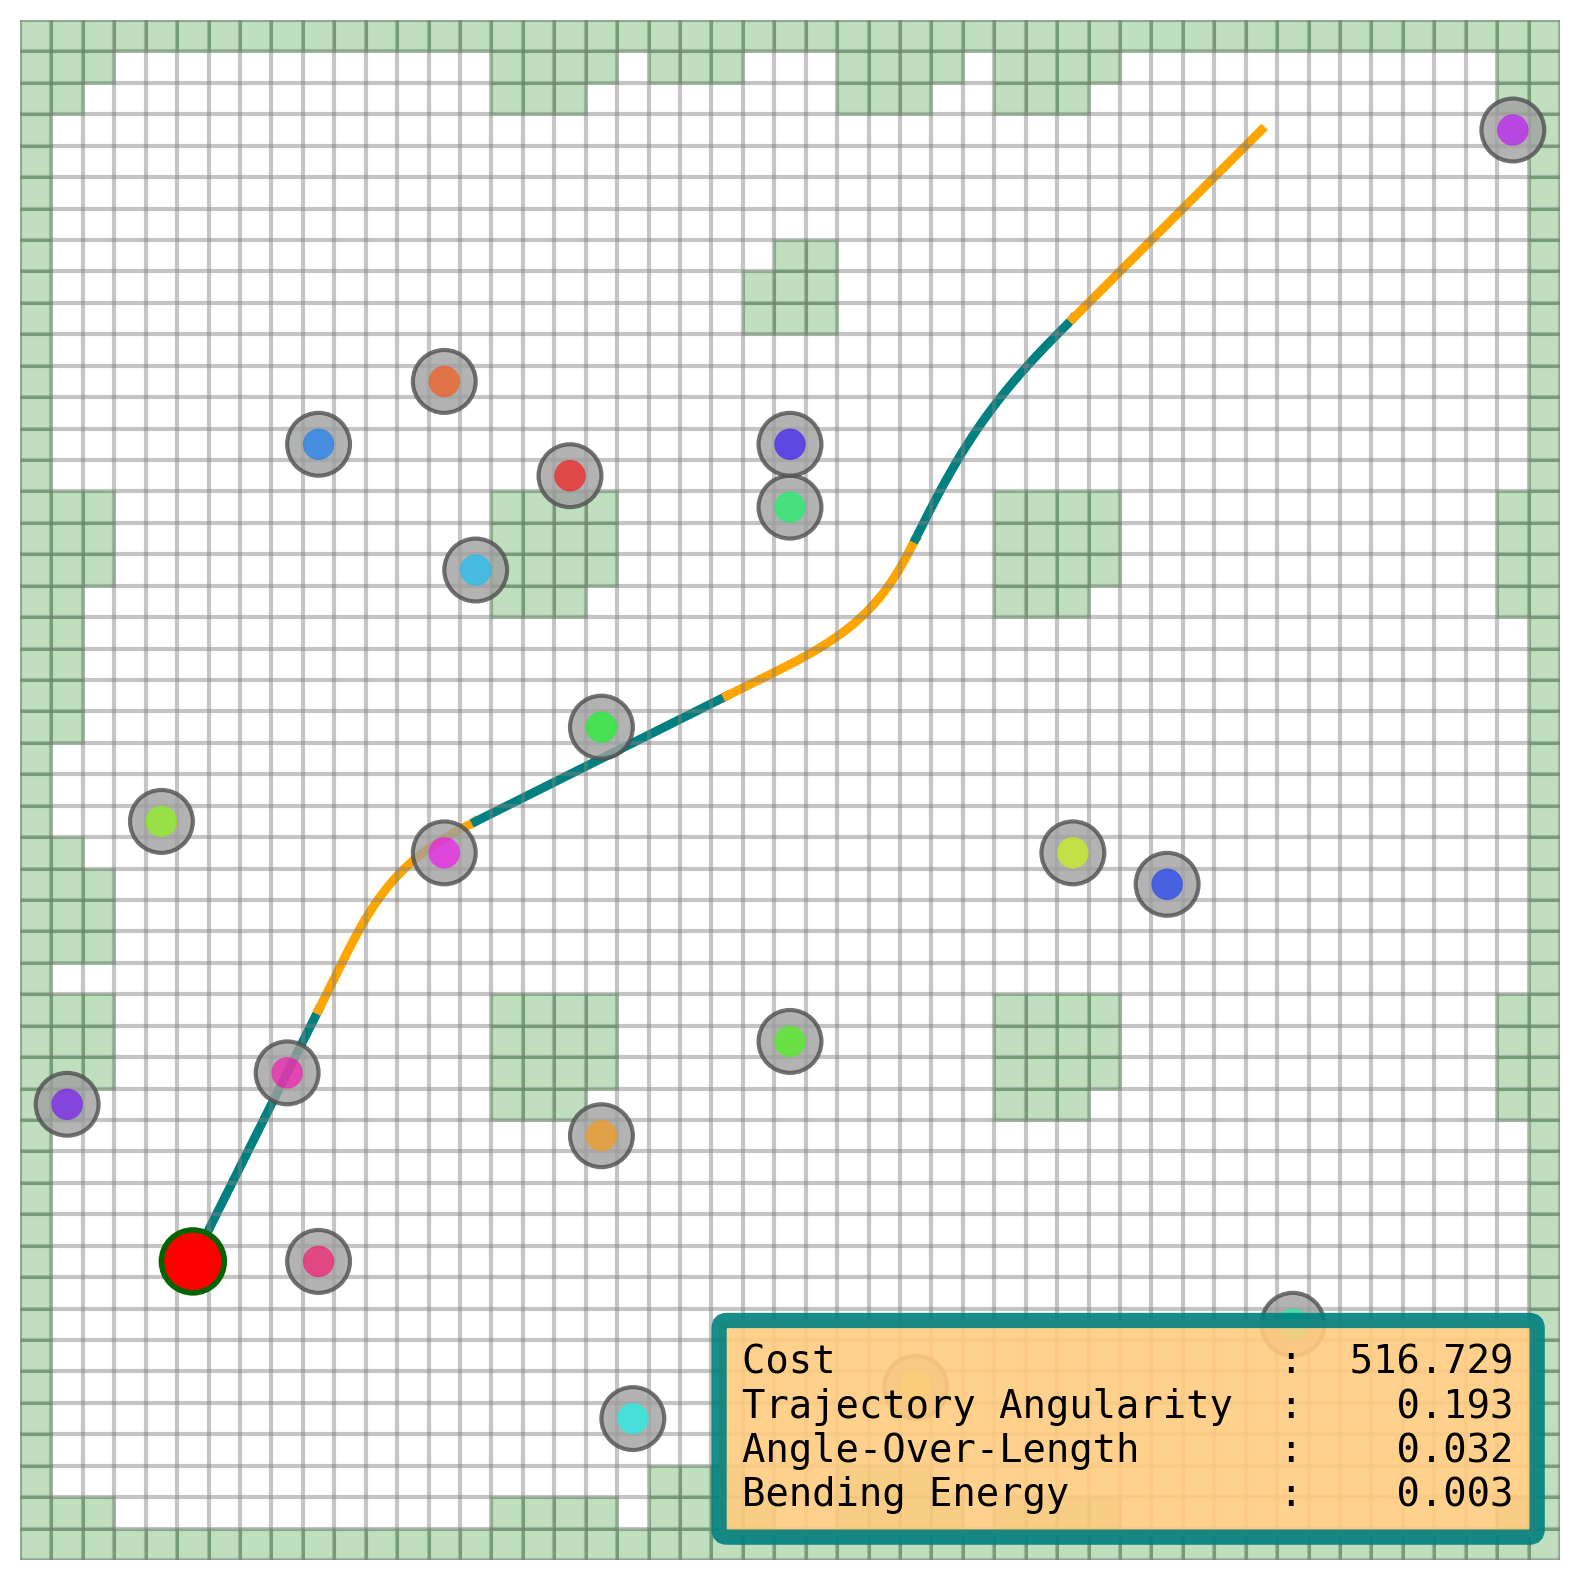

[arena_extended] Pathfinding Success: True | Cost: 508.0


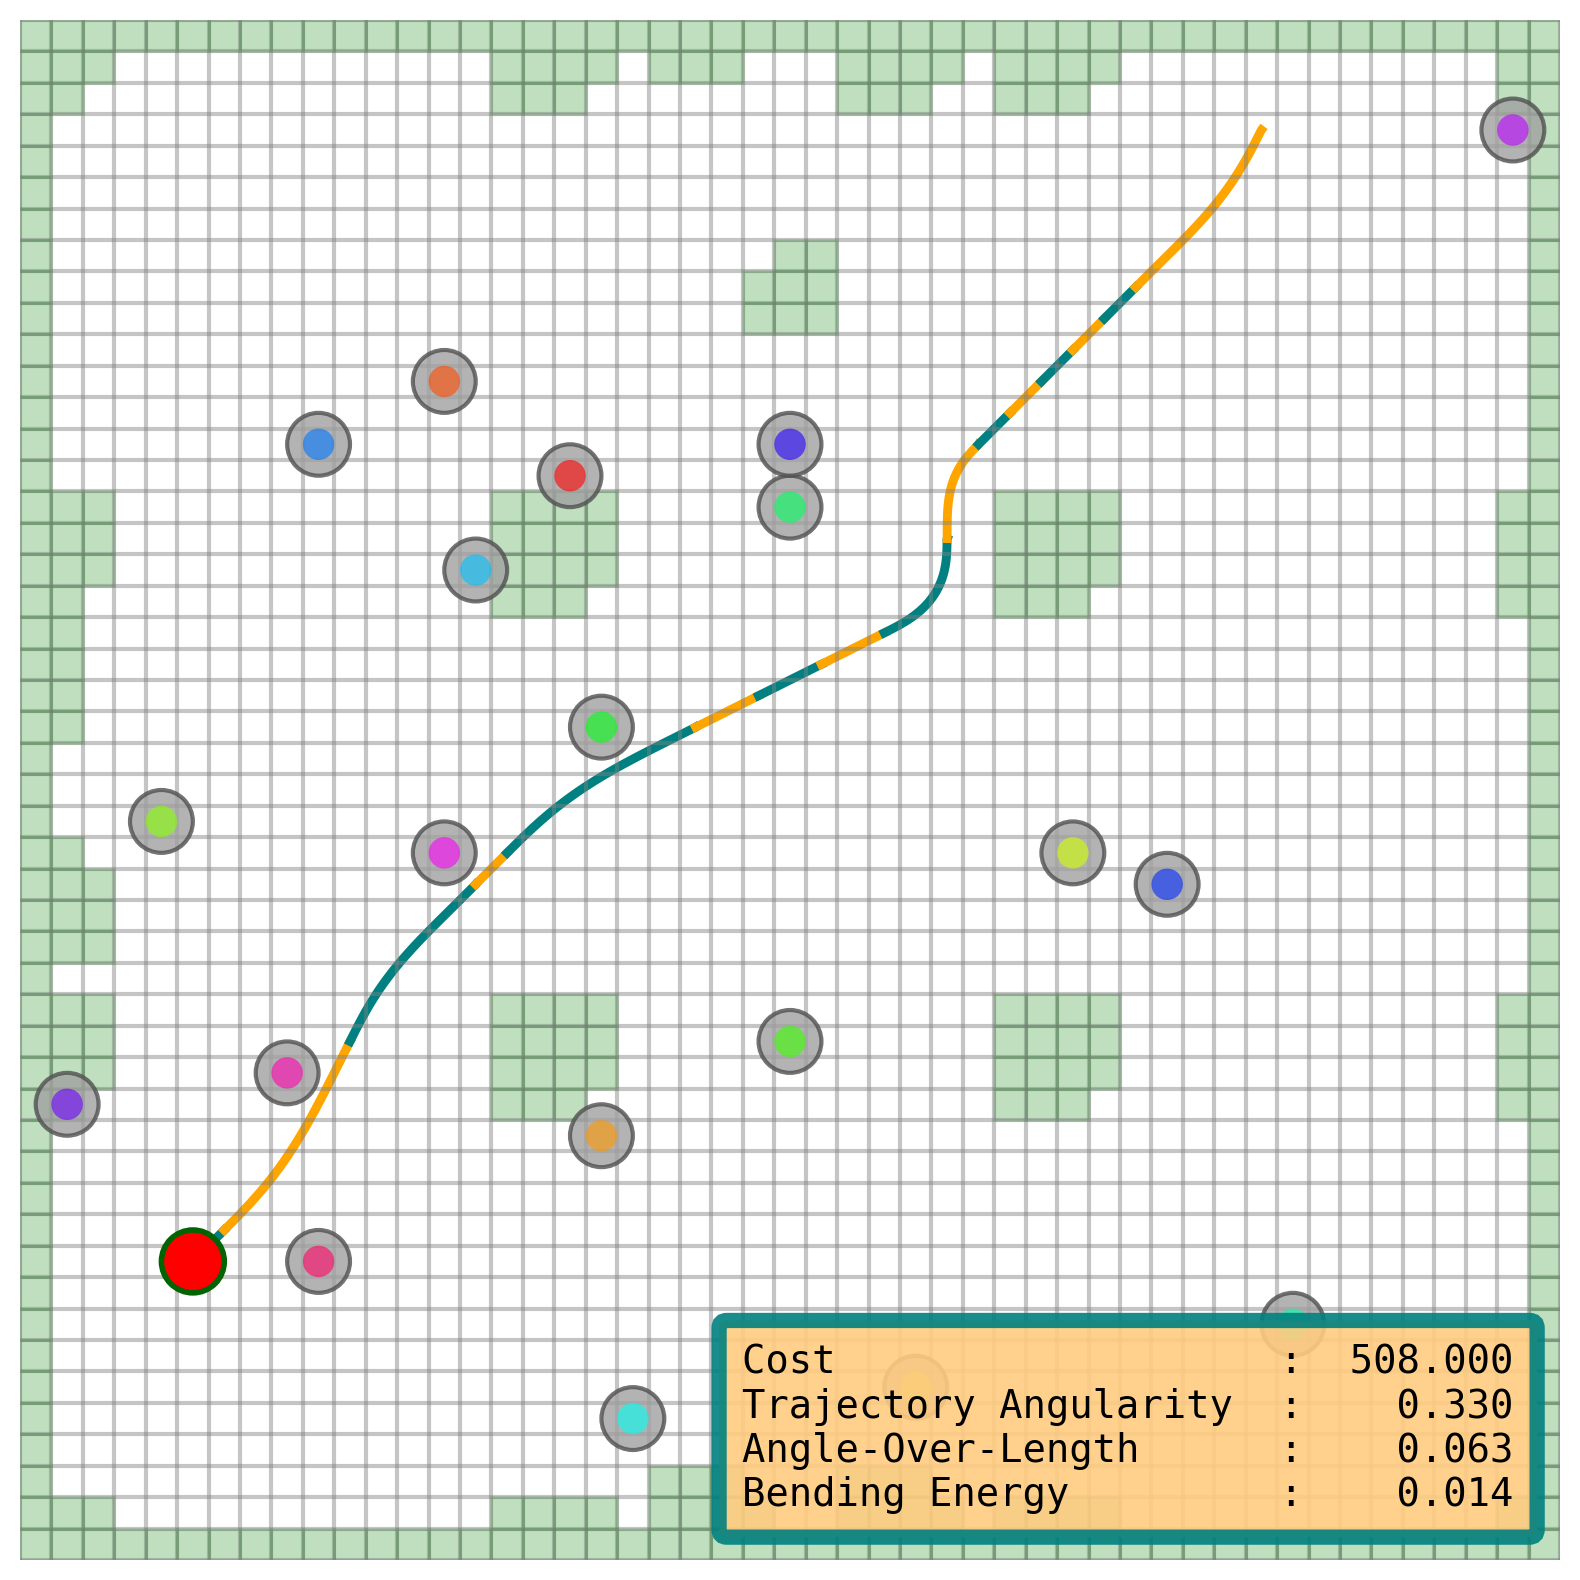

[arena_cs2] Pathfinding Success: True | Cost: 700.0


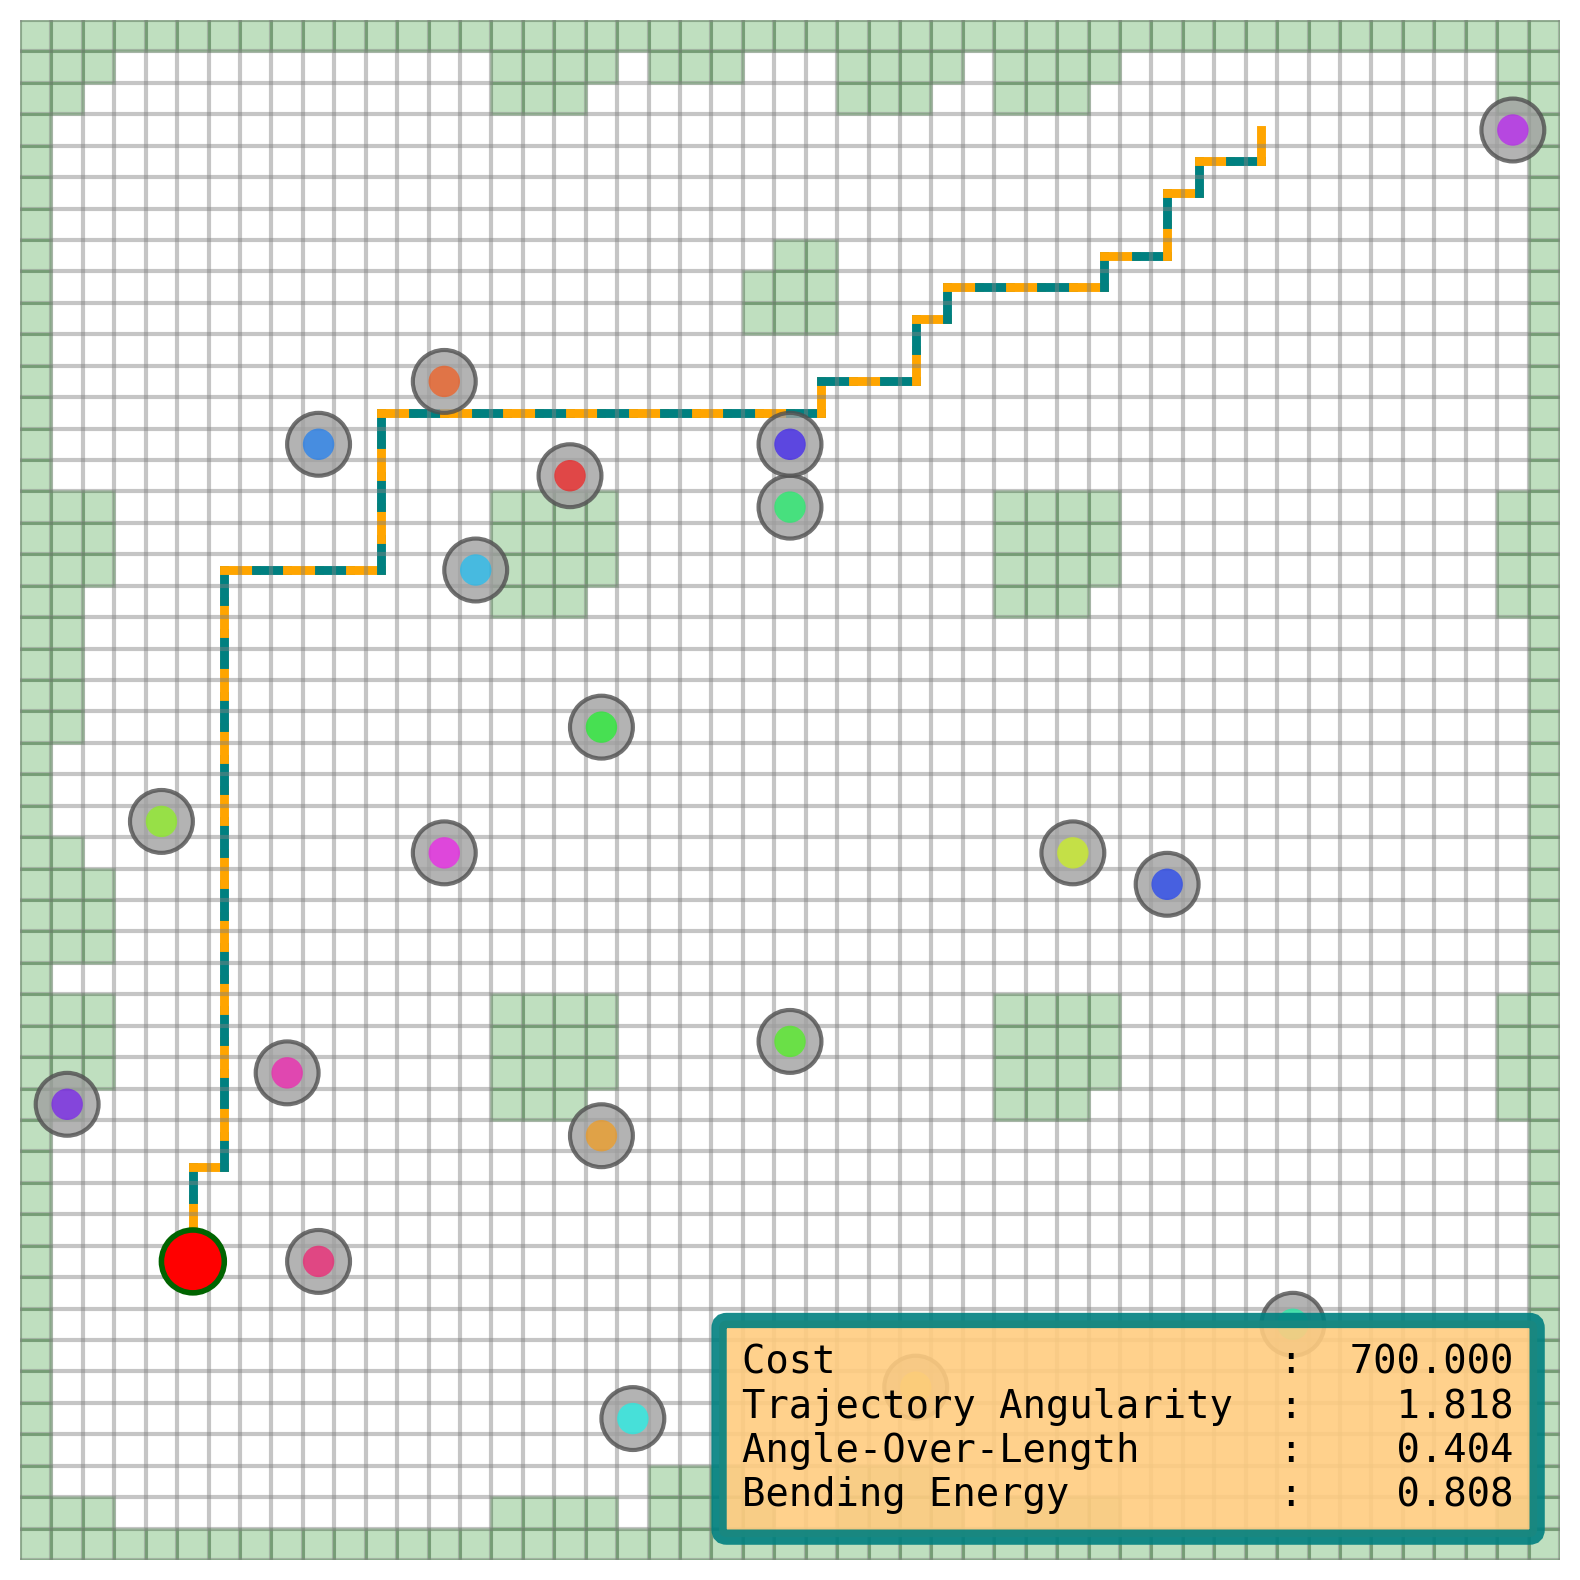

[arena_cs3] Pathfinding Success: True | Cost: 514.7716519999999


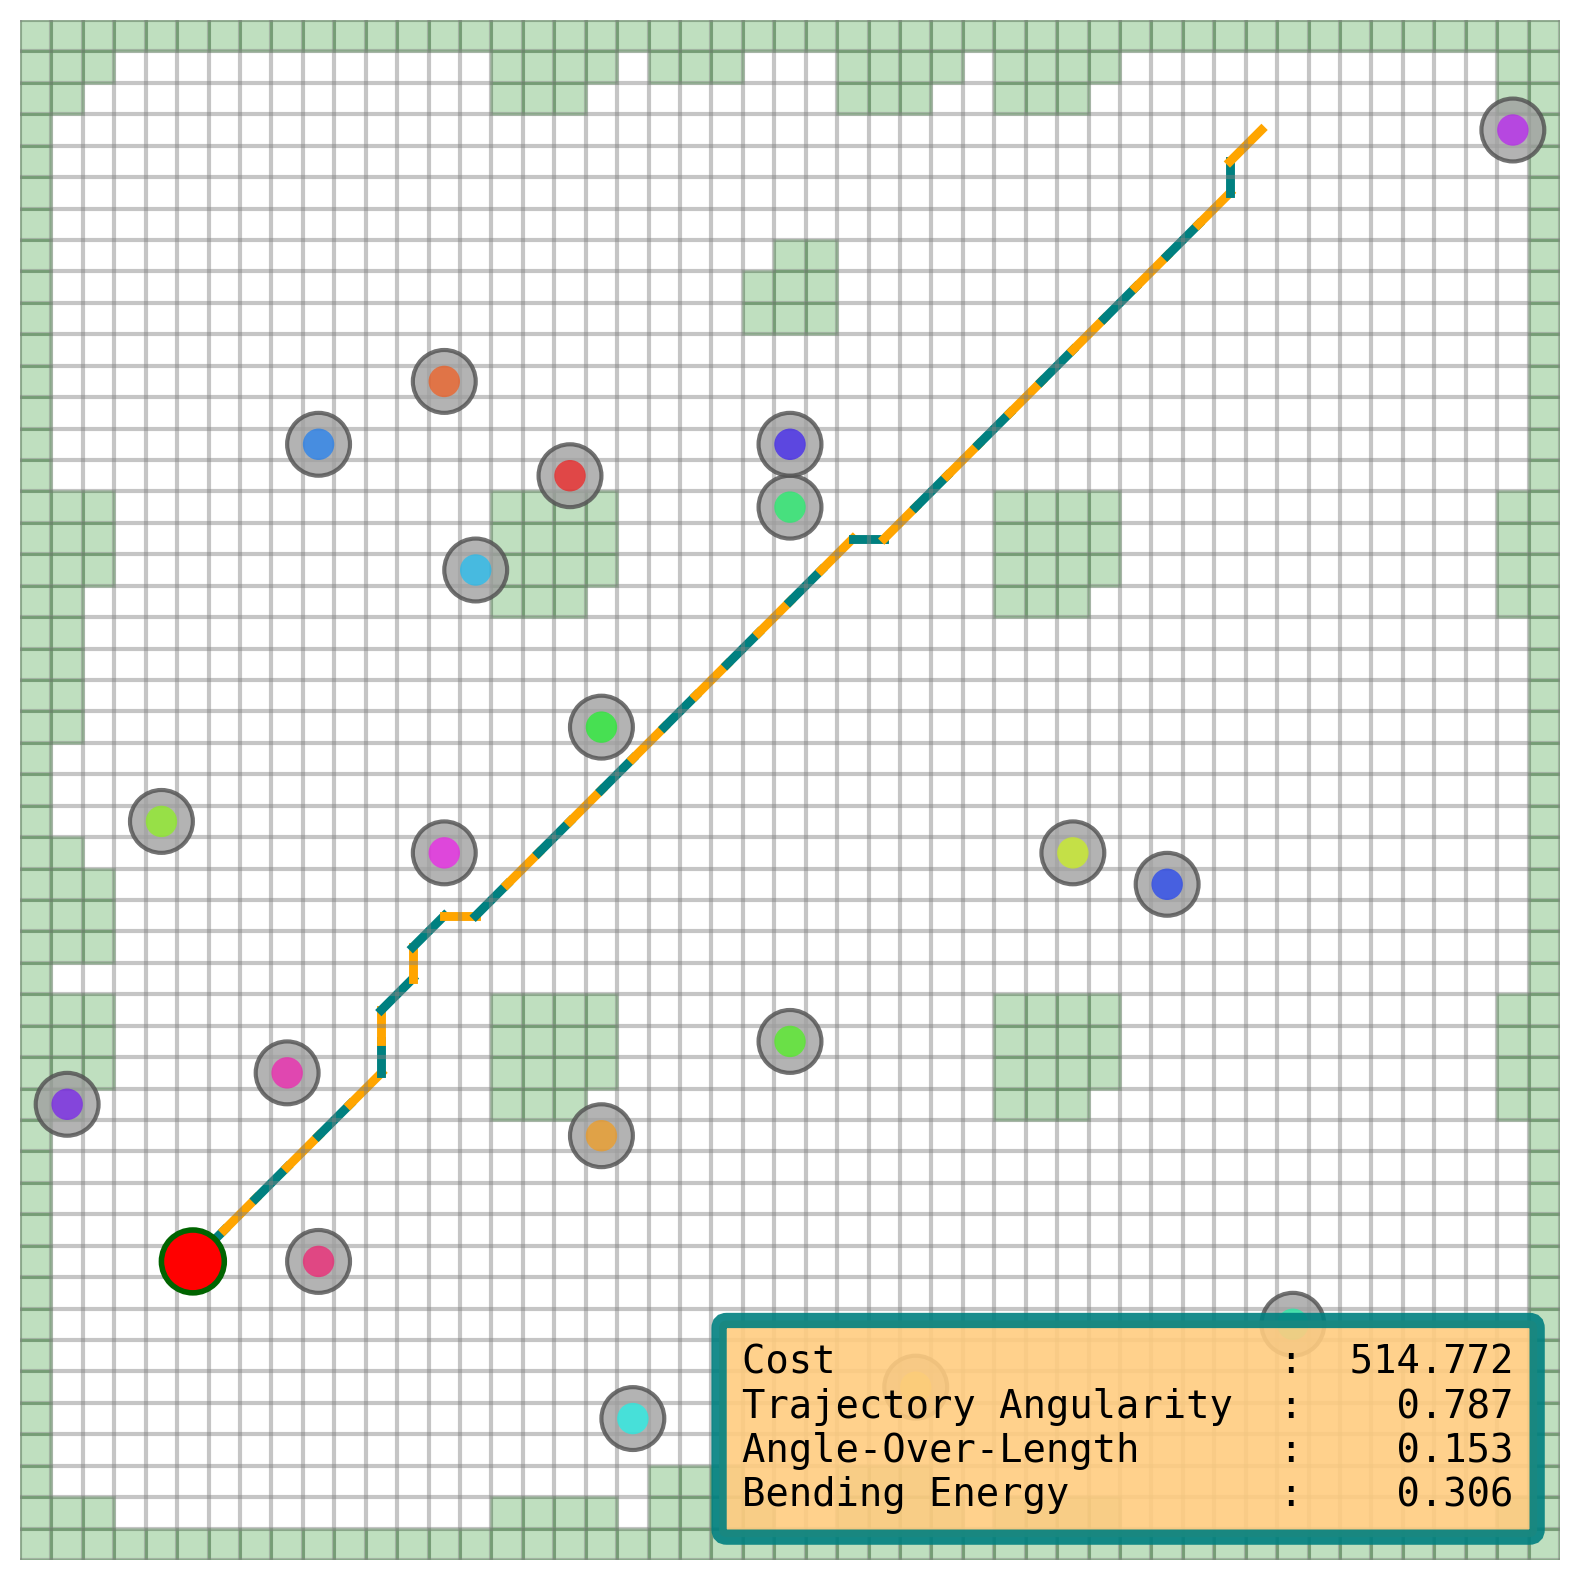

[arena_cs4] Pathfinding Success: True | Cost: 510.5259279999999


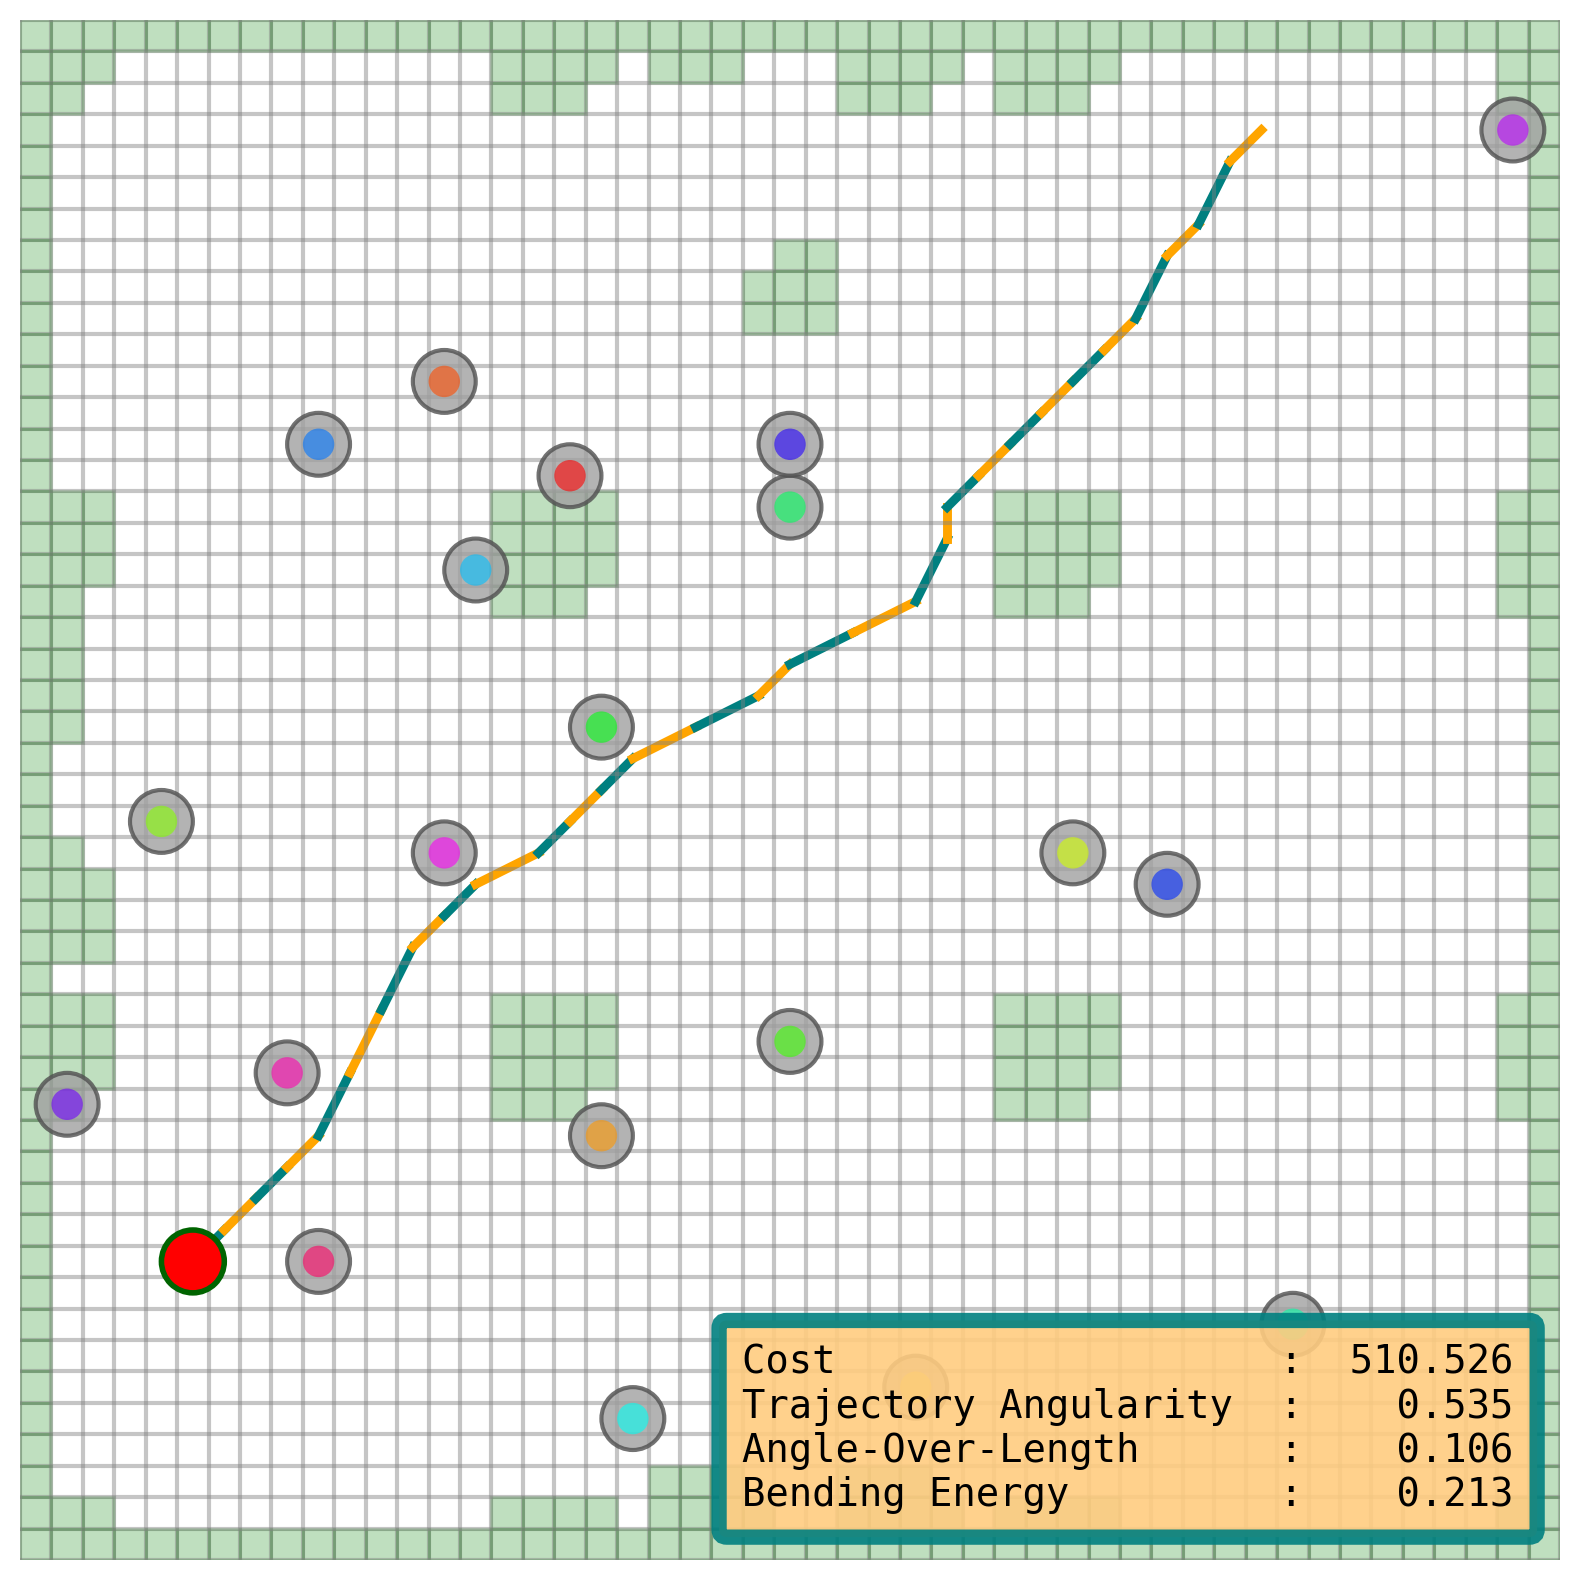

[arena_cs5] Pathfinding Success: True | Cost: 507.5437539999999


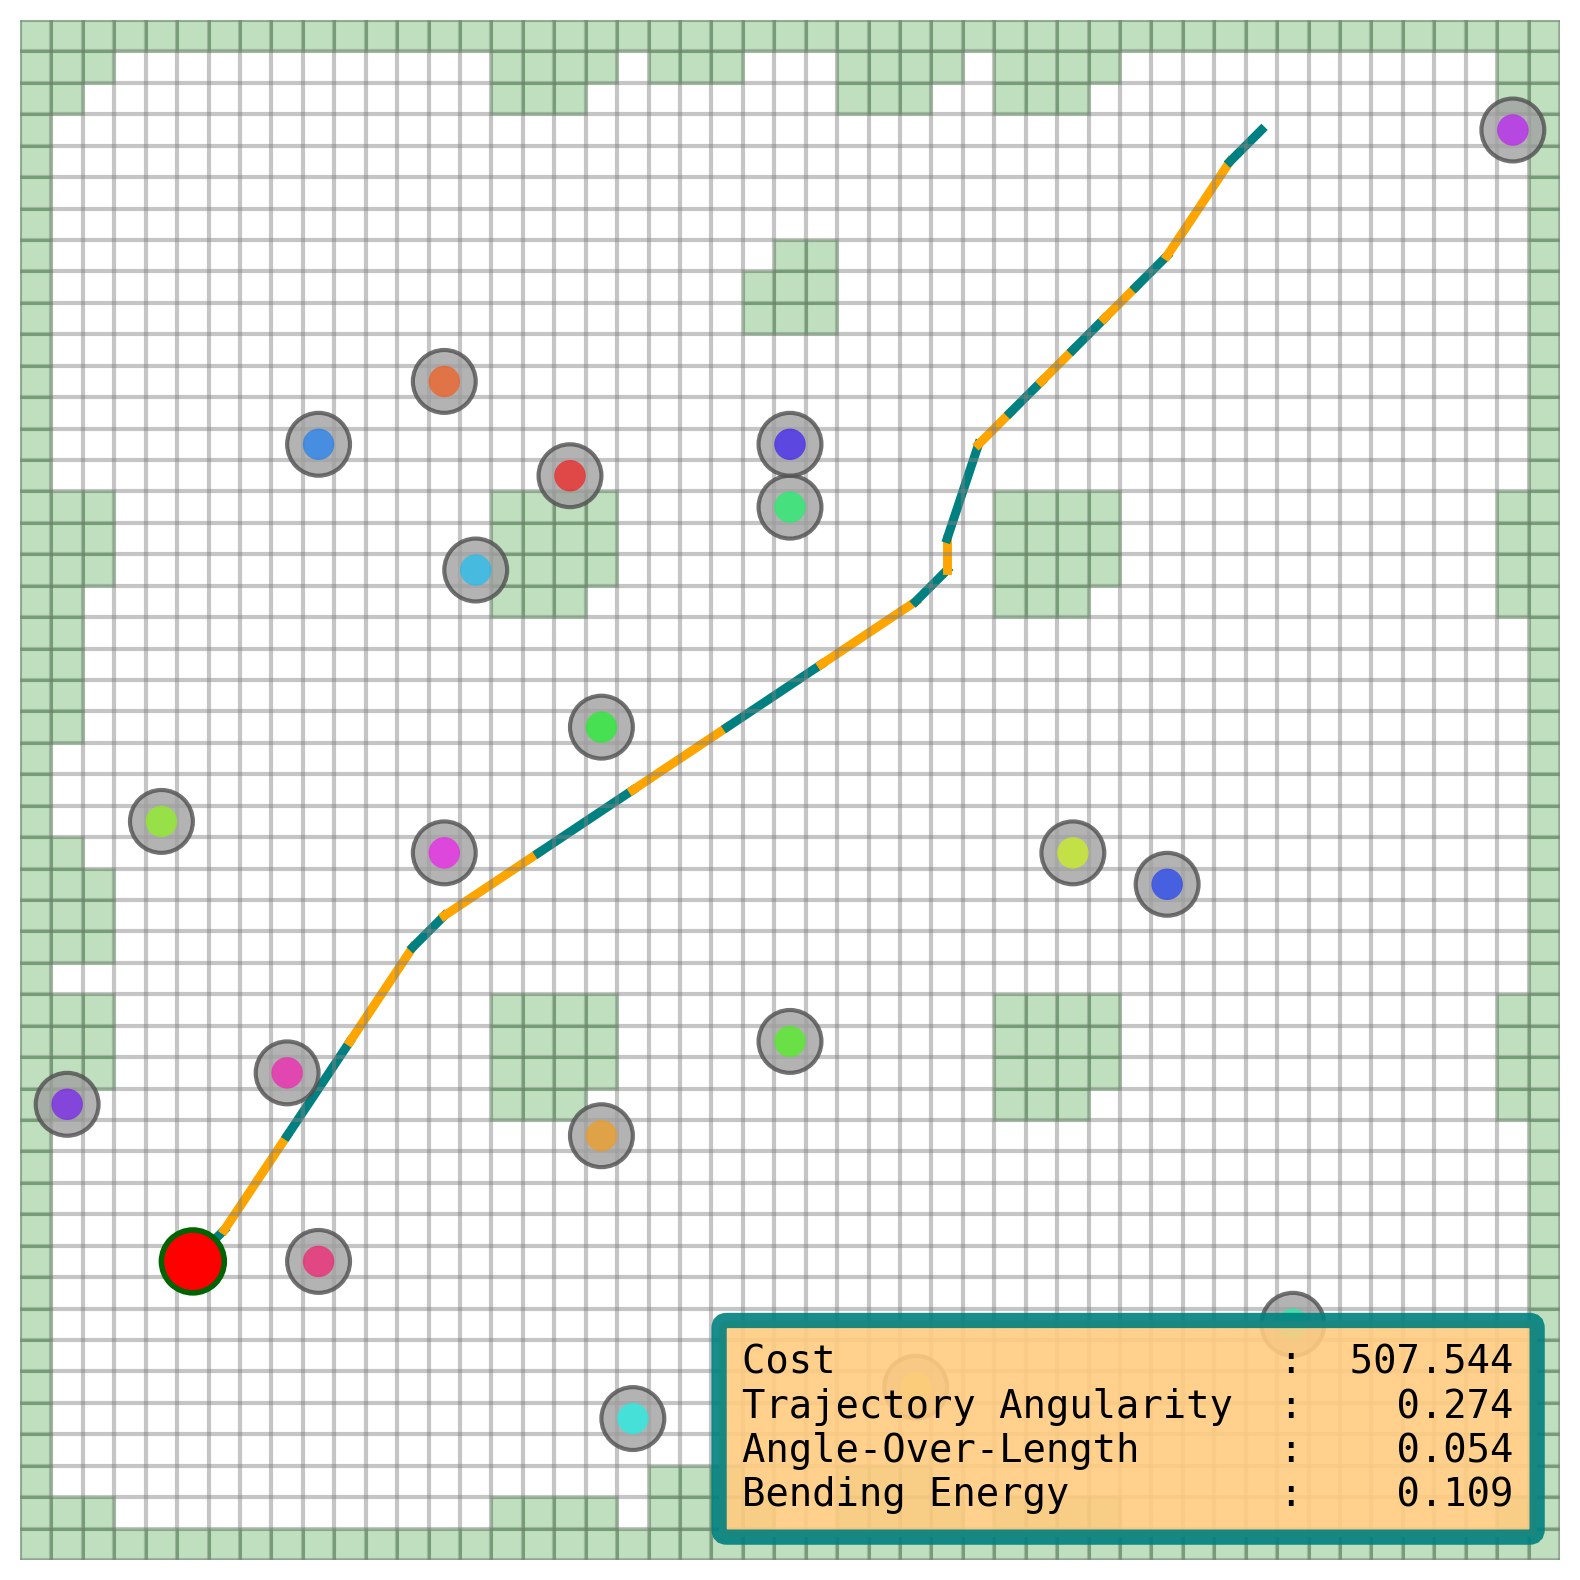

In [6]:
# Batch Evaluation Loop
for name, cs in zip(['arena_basic', 'arena_extended', 'arena_cs2', 'arena_cs3', 'arena_cs4', 'arena_cs5'],
                    control_sets):
    # Generate and save the annotated trajectory plot
    # NOTE: 'is_angular' tracks whether the primitive set accounts for kinodynamic orientation (theta),
    # here it is Automatically False for 2^k lattices where 'cs' is in the string
    fig = generate_annotated_snapshot(name, cs, environment, task_map, start, goal, is_angular=("cs" in name), save_dir="../media/")
    if fig is not None:
        display(fig)